In [ ]:
import pandas as pd
df = pd.read_csv('/content/fertilizer.csv')

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("fertilizer.csv")

print(df.head())
print(df.shape)

   Temparature  Humidity   Moisture Soil Type  Crop Type  Nitrogen  Potassium  \
0           26         52        38     Sandy      Maize        37          0   
1           29         52        45     Loamy  Sugarcane        12          0   
2           34         65        62     Black     Cotton         7          9   
3           32         62        34       Red    Tobacco        22          0   
4           28         54        46    Clayey      Paddy        35          0   

   Phosphorous Fertilizer Name  
0            0            Urea  
1           36             DAP  
2           30        14-35-14  
3           20           28-28  
4            0            Urea  
(99, 9)


In [ ]:
print(df.isnull().sum())

Temparature        0
Humidity           0
Moisture           0
Soil Type          0
Crop Type          0
Nitrogen           0
Potassium          0
Phosphorous        0
Fertilizer Name    0
dtype: int64


In [ ]:
df = df.dropna()

In [ ]:
label_encoders = {}

categorical_cols = ['Soil Type', 'Crop Type', 'Fertilizer Name']

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [ ]:
print(df.head())

   Temparature  Humidity   Moisture  Soil Type  Crop Type  Nitrogen  \
0           26         52        38          4          3        37   
1           29         52        45          2          8        12   
2           34         65        62          0          1         7   
3           32         62        34          3          9        22   
4           28         54        46          1          6        35   

   Potassium  Phosphorous  Fertilizer Name  
0          0            0                6  
1          0           36                5  
2          9           30                1  
3          0           20                4  
4          0            0                6  


In [ ]:
X = df.drop('Fertilizer Name', axis=1)

y = df['Fertilizer Name']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric='mlogloss'
    ),

    "SVM": SVC(
        kernel='rbf',
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,50),
        max_iter=1000,
        random_state=42
    )
}

In [ ]:
results = []

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Models needing scaled data
    if name in ["SVM", "KNN", "MLP"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average='weighted'
    )

    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print(classification_report(y_test, y_pred))


Training Random Forest...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20


Training XGBoost...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

              precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         4
           6       1.00      1.00      1.00         5

    accuracy                           0.95        20
   macro avg       0.79      0.86      0.81        20
weighted avg       0.93      0.95      0.93        20



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

print(results_df)

           Model  Accuracy  Precision  Recall  F1-Score
0  Random Forest      1.00      1.000    1.00  1.000000
1        XGBoost      1.00      1.000    1.00  1.000000
2            SVM      1.00      1.000    1.00  1.000000
3            KNN      0.90      0.875    0.90  0.883333
4            MLP      0.95      0.925    0.95  0.933333


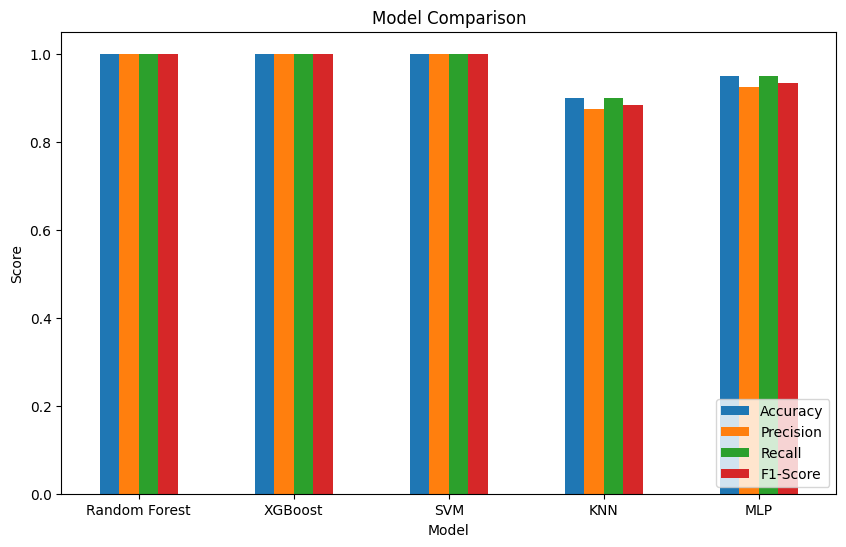

In [ ]:
results_df.set_index("Model").plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Model Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

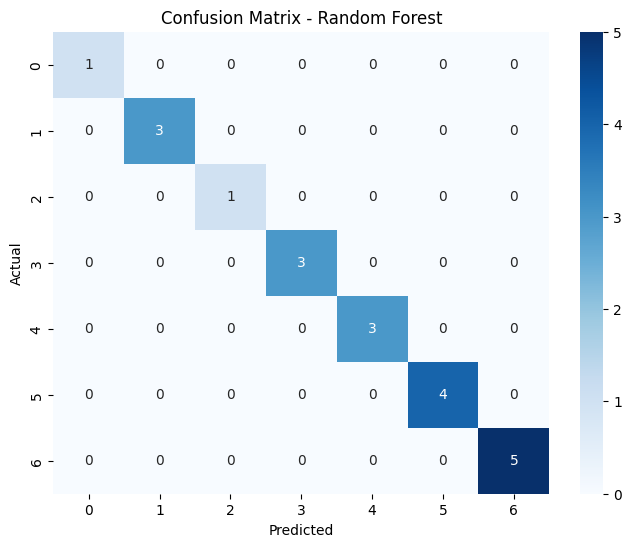

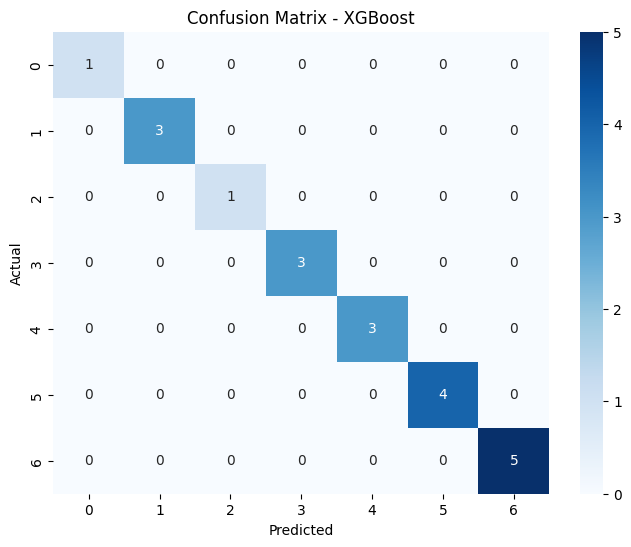

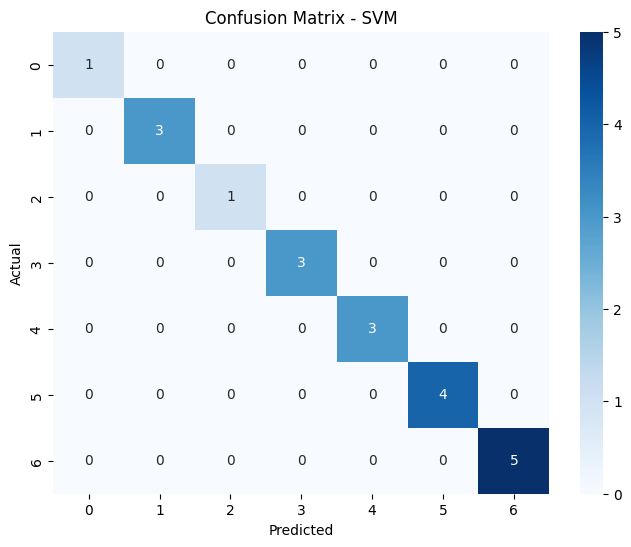

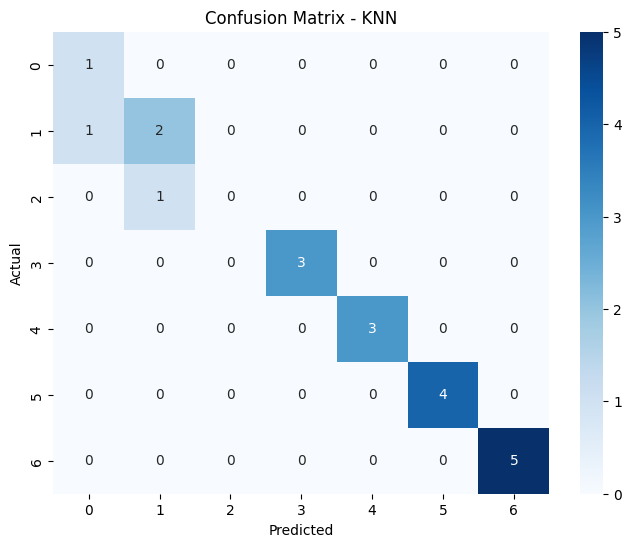

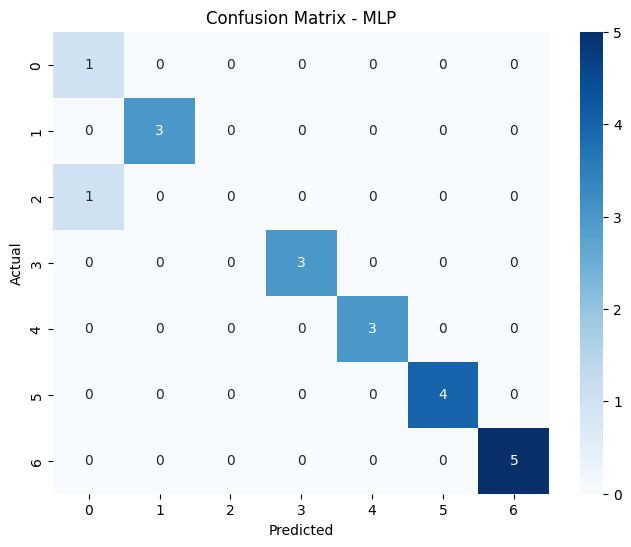

In [ ]:
for name, model in models.items():

    if name in ["SVM", "KNN", "MLP"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [ ]:
best_model = results_df.loc[
    results_df['Accuracy'].idxmax()
]

print("Best Model:")
print(best_model)

Best Model:
Model        Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1-Score               1.0
Name: 0, dtype: object


In [ ]:
import joblib

rf_model = models["Random Forest"]

joblib.dump(rf_model, "fertilizer_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
new_sample = pd.DataFrame({
    'Temparature':[28],
    'Humidity':[60],
    'Moisture':[40],
    'Soil Type':[1],
    'Crop Type':[3],
    'Nitrogen':[25],
    'Potassium':[20],
    'Phosphorous':[15]
})

# Align columns of new_sample with X_train to ensure correct order and names
new_sample = new_sample.reindex(columns=X_train.columns)

prediction = rf_model.predict(new_sample)

fertilizer_name = label_encoders[
    'Fertilizer Name'
].inverse_transform(prediction)

print("Recommended Fertilizer:",
      fertilizer_name[0])

Recommended Fertilizer: 28-28


In [ ]:
# ==============================
# INSTALL LIBRARIES
# ==============================
!pip install -q xgboost gradio

# ==============================
# IMPORTS
# ==============================
import pandas as pd
import numpy as np
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier

# ==============================
# LOAD DATASET
# ==============================
df = pd.read_csv("/content/fertilizer.csv")

# Dataset columns example:
# Temperature, Humidity, Moisture,
# Soil Type, Crop Type,
# Nitrogen, Potassium, Phosphorous,
# Fertilizer Name

# ==============================
# ENCODE CATEGORICAL DATA
# ==============================
soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
fert_encoder = LabelEncoder()

df["Soil Type"] = soil_encoder.fit_transform(df["Soil Type"])
df["Crop Type"] = crop_encoder.fit_transform(df["Crop Type"])
df["Fertilizer Name"] = fert_encoder.fit_transform(df["Fertilizer Name"])

# ==============================
# FEATURES & TARGET
# ==============================
X = df.drop("Fertilizer Name", axis=1)
y = df["Fertilizer Name"]

# ==============================
# TRAIN TEST SPLIT
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==============================
# SCALING
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==============================
# TRAIN ALL MODELS
# ==============================
models = {
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="mlogloss"
    ),

    "SVM": SVC(probability=True),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "MLP": MLPClassifier(
        hidden_layer_sizes=(100,50),
        max_iter=1000
    )
}

results = {}

best_model = None
best_accuracy = 0

for name, model in models.items():

    if name in ["SVM","KNN","MLP"]:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)

    results[name] = acc

    if acc > best_accuracy:
        best_accuracy = acc
        best_model = model
        best_model_name = name

print("Best Model:", best_model_name)
print("Accuracy:", round(best_accuracy*100,2), "%")

# ==============================
# PREDICTION FUNCTION
# ==============================
def fertilizer_ai(
    temperature,
    humidity,
    moisture,
    soil,
    crop,
    nitrogen,
    potassium,
    phosphorus
):

    soil_val = soil_encoder.transform([soil])[0]
    crop_val = crop_encoder.transform([crop])[0]

    data = np.array([[
        temperature,
        humidity,
        moisture,
        soil_val,
        crop_val,
        nitrogen,
        potassium,
        phosphorus
    ]])

    if best_model_name in ["SVM","KNN","MLP"]:
        data = scaler.transform(data)

    prediction = best_model.predict(data)

    fertilizer = fert_encoder.inverse_transform(prediction)[0]

    explanation = f"""
🌱 Recommended Fertilizer: {fertilizer}

📌 Crop Type: {crop}
📌 Soil Type: {soil}

NPK Analysis:
• Nitrogen = {nitrogen}
• Phosphorus = {phosphorus}
• Potassium = {potassium}

The trained {best_model_name} model predicts that
'{fertilizer}' is the most suitable fertilizer for
the given soil and crop conditions.

Model Accuracy: {round(best_accuracy*100,2)}%
"""

    return fertilizer, explanation

# ==============================
# SINGLE PAGE GRADIO UI
# ==============================
with gr.Blocks(theme=gr.themes.Soft()) as demo:

    gr.Markdown(
        "# 🌾 AI Fertilizer Recommendation System"
    )

    with gr.Row():

        with gr.Column():

            temperature = gr.Number(label="Temperature")

            humidity = gr.Number(label="Humidity")

            moisture = gr.Number(label="Moisture")

            soil = gr.Dropdown(
                choices=list(soil_encoder.classes_),
                label="Soil Type"
            )

            crop = gr.Dropdown(
                choices=list(crop_encoder.classes_),
                label="Crop Type"
            )

            nitrogen = gr.Number(label="Nitrogen")

            potassium = gr.Number(label="Potassium")

            phosphorus = gr.Number(label="Phosphorus")

            submit = gr.Button("Predict Fertilizer")

        with gr.Column():

            fertilizer_output = gr.Textbox(
                label="Recommended Fertilizer"
            )

            explanation_output = gr.Textbox(
                label="AI Recommendation Report",
                lines=15
            )

    submit.click(
        fertilizer_ai,
        inputs=[
            temperature,
            humidity,
            moisture,
            soil,
            crop,
            nitrogen,
            potassium,
            phosphorus
        ],
        outputs=[
            fertilizer_output,
            explanation_output
        ]
    )

# ==============================
# PUBLIC WEBSITE
# ==============================
demo.launch(share=True)

Best Model: Random Forest
Accuracy: 100.0 %


/tmp/ipykernel_3131/2825737307.py:180: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://1613ff33319578cd09.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
